In [7]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from PIL import Image
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR  = Path(r"C:\Users\ishas\OneDrive\Desktop\ML\Ecolens")
MODEL_DIR = BASE_DIR / "models"
DATA_DIR  = BASE_DIR / "data"
TEST_DIR  = DATA_DIR / "test"

CLASS_NAMES  = sorted([d.name for d in (DATA_DIR/"train").iterdir() if d.is_dir()])
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}

print("Device     :", device)
print("Classes    :", CLASS_NAMES)
print("All imports OK")

Device     : cpu
Classes    : ['glass', 'hazardous', 'metal', 'non_recyclable_trash', 'organic_biodegradable', 'paper_cardboard', 'recyclable_plastic']
All imports OK


In [8]:
def build_model(num_classes=7, dropout=0.4):
    model = models.efficientnet_b4(
        weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1
    )
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes)
    )
    return model

checkpoint = torch.load(
    MODEL_DIR / "best_model.pth",
    map_location=device
)
model = build_model(num_classes=len(CLASS_NAMES))
model.load_state_dict(checkpoint['model_state'])
model = model.to(device)
model.eval()

print(f"Model loaded — Val acc: {checkpoint['val_acc']}%")

Model loaded — Val acc: 89.01312591152163%


In [9]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.target_layer = target_layer
        self.gradients   = None
        self.activations = None
        
        # Forward hook — captures layer output
        self.target_layer.register_forward_hook(self._save_activation)
        
        # Backward hook — use register_backward_hook instead
        self.target_layer.register_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        # grad_output[0] contains the gradients we need
        self.gradients = grad_output[0].detach()
    
    def generate(self, input_tensor, class_idx=None):
        # Must enable gradients for backward pass
        input_tensor = input_tensor.requires_grad_(True)
        
        # Forward pass
        self.model.zero_grad()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        # Backward pass for target class
        score = output[0, class_idx]
        score.backward(retain_graph=True)
        
        # Debug check
        if self.gradients is None:
            print("WARNING: gradients not captured")
            return None, class_idx, output.softmax(dim=1)[0]
        
        # Pool gradients across spatial dimensions
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        
        # Weighted activation map
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        
        # ReLU — keep only positive values
        cam = torch.relu(cam)
        
        # Normalize to 0-1
        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        
        return cam, class_idx, output.softmax(dim=1)[0].detach()

# Reattach to model
target_layer = model.features[8]
gradcam      = GradCAM(model, target_layer)

# Quick test to verify hooks work
test_input = torch.randn(1, 3, 224, 224).to(device)
cam, pred, probs = gradcam.generate(test_input)

if cam is not None:
    print("GradCAM working correctly!")
    print(f"CAM shape: {cam.shape}")
    print(f"Predicted class: {IDX_TO_CLASS[pred]}")
else:
    print("Hook still not capturing — trying alternative")

print("Ready to generate heatmaps")

C:\ProgramData\anaconda3\envs\ecolens\lib\site-packages\torch\nn\modules\module.py:1869: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


GradCAM working correctly!
CAM shape: (7, 7)
Predicted class: glass
Ready to generate heatmaps


In [10]:
def preprocess_image(img_path):
    """Load and preprocess one image for model input"""
    transform = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])
    image     = Image.open(str(img_path)).convert("RGB")
    image_np  = np.array(image)
    tensor    = transform(image=image_np)["image"].unsqueeze(0)
    return tensor.to(device), image_np


def overlay_heatmap(original_img, cam, alpha=0.5):
    """Overlay Grad-CAM heatmap on original image"""
    # Resize CAM to match original image
    cam_resized = cv2.resize(cam, (original_img.shape[1], original_img.shape[0]))
    
    # Apply colormap — jet gives red=high attention, blue=low
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized), cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Blend heatmap with original image
    overlay = (alpha * heatmap + (1 - alpha) * original_img).astype(np.uint8)
    return overlay, heatmap


def visualize_gradcam(img_path, gradcam, idx_to_class, save_path=None):
    """Full pipeline: load → predict → generate cam → visualize"""
    
    # Preprocess
    input_tensor, original_img = preprocess_image(img_path)
    
    # Resize original for display
    original_resized = cv2.resize(original_img, (224, 224))
    
    # Generate Grad-CAM
    cam, pred_idx, probs = gradcam.generate(input_tensor)
    
    # Create overlay
    overlay, heatmap = overlay_heatmap(original_resized, cam)
    
    # Get top 3 predictions
    top3_probs, top3_idx = probs.topk(3)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    axes[0].imshow(original_resized)
    axes[0].set_title("Original Image", fontsize=11)
    axes[0].axis('off')
    
    axes[1].imshow(heatmap)
    axes[1].set_title("Grad-CAM Heatmap\n(red = model focused here)", fontsize=11)
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    pred_class = idx_to_class[pred_idx]
    axes[2].set_title(f"Overlay\nPredicted: {pred_class}", fontsize=11)
    axes[2].axis('off')
    
    # Add probability bar
    fig.text(0.5, -0.05,
             f"Top predictions:  " +
             "  |  ".join([
                 f"{idx_to_class[top3_idx[i].item()]}: "
                 f"{top3_probs[i].item()*100:.1f}%"
                 for i in range(3)
             ]),
             ha='center', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return pred_idx, probs

print("Helper functions ready!")

Helper functions ready!


Generating Grad-CAM heatmaps for all 7 classes...

Class: glass
Saved: C:\Users\ishas\OneDrive\Desktop\ML\Ecolens\models\gradcam_outputs\gradcam_glass.png


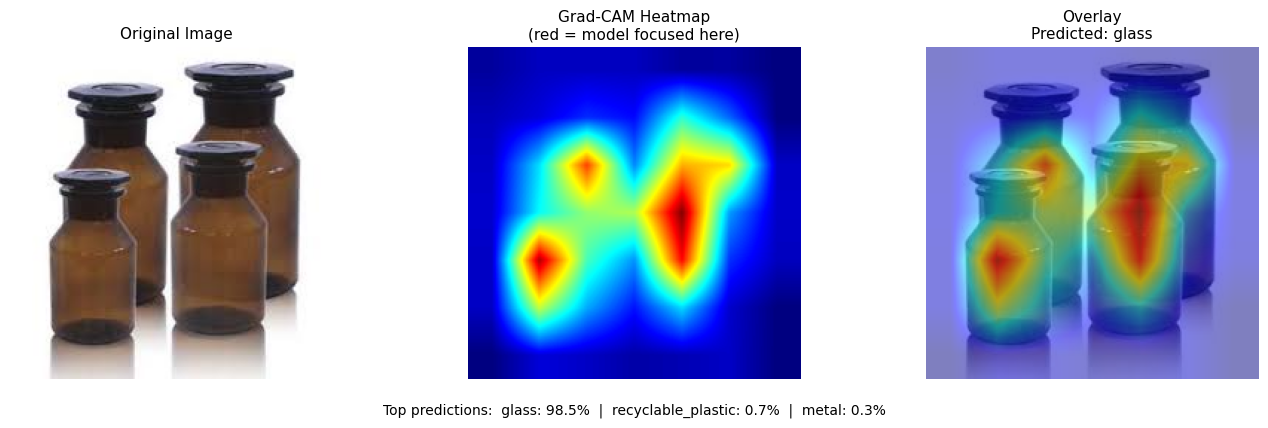

Predicted: glass (98.5% confidence)

Class: hazardous
Saved: C:\Users\ishas\OneDrive\Desktop\ML\Ecolens\models\gradcam_outputs\gradcam_hazardous.png


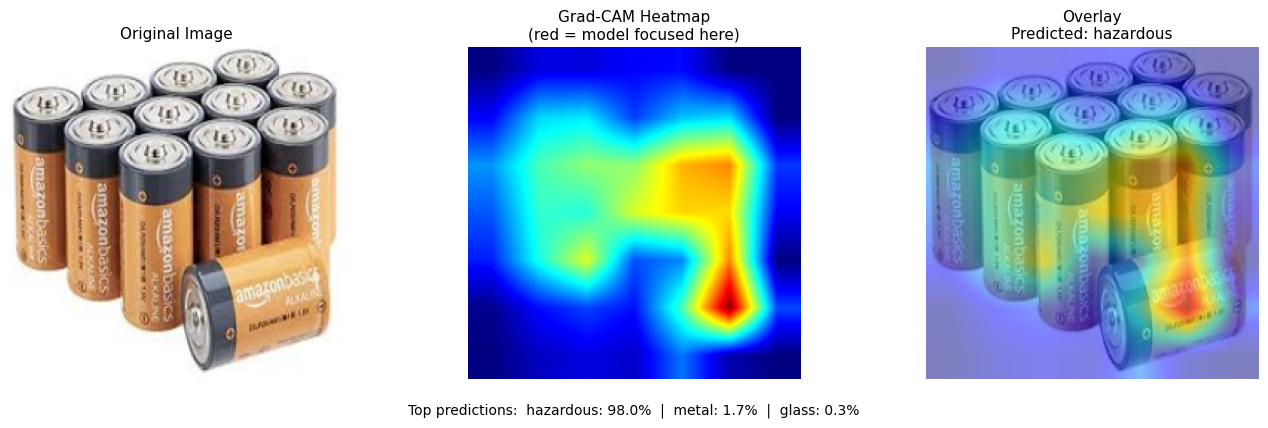

Predicted: hazardous (98.0% confidence)

Class: metal
Saved: C:\Users\ishas\OneDrive\Desktop\ML\Ecolens\models\gradcam_outputs\gradcam_metal.png


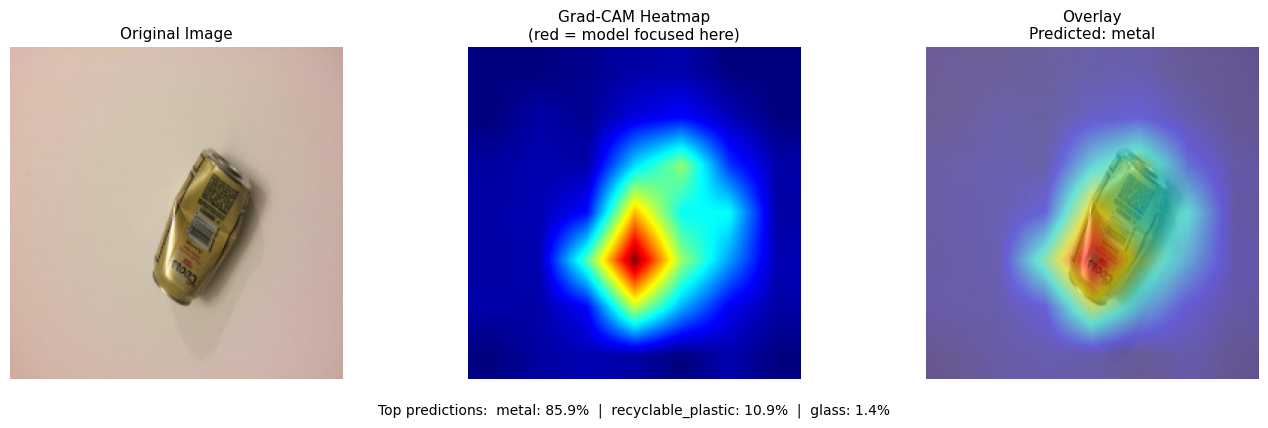

Predicted: metal (85.9% confidence)

Class: non_recyclable_trash
Saved: C:\Users\ishas\OneDrive\Desktop\ML\Ecolens\models\gradcam_outputs\gradcam_non_recyclable_trash.png


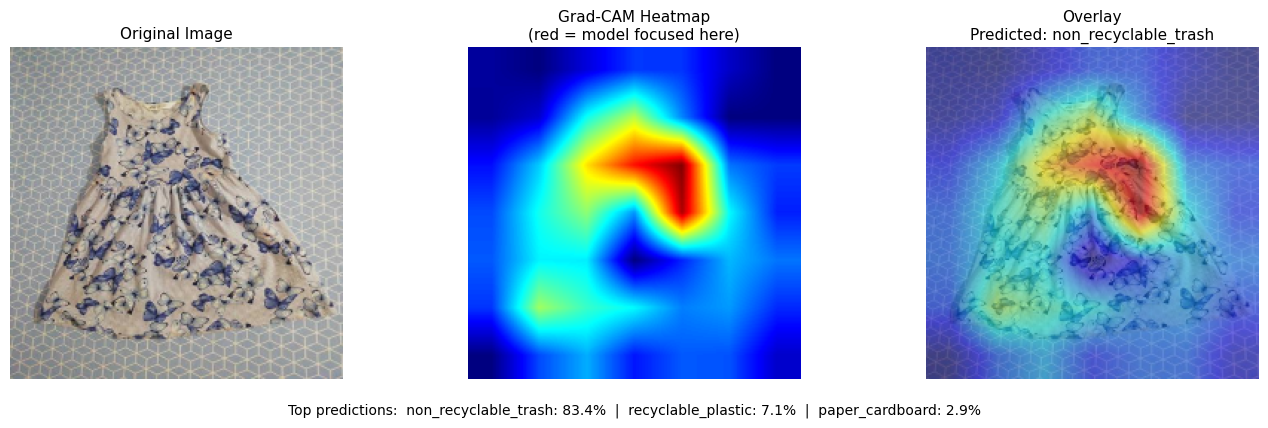

Predicted: non_recyclable_trash (83.4% confidence)

Class: organic_biodegradable
Saved: C:\Users\ishas\OneDrive\Desktop\ML\Ecolens\models\gradcam_outputs\gradcam_organic_biodegradable.png


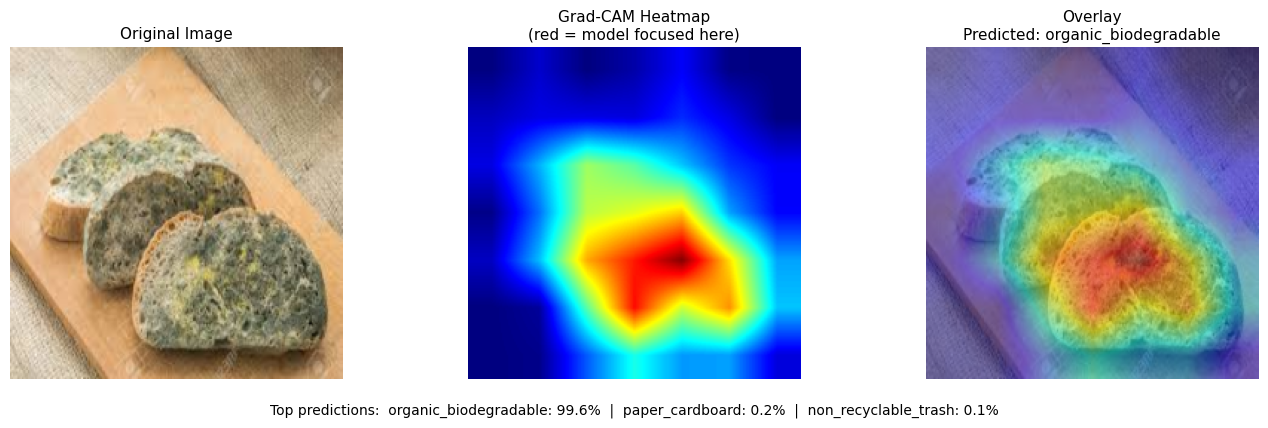

Predicted: organic_biodegradable (99.6% confidence)

Class: paper_cardboard
Saved: C:\Users\ishas\OneDrive\Desktop\ML\Ecolens\models\gradcam_outputs\gradcam_paper_cardboard.png


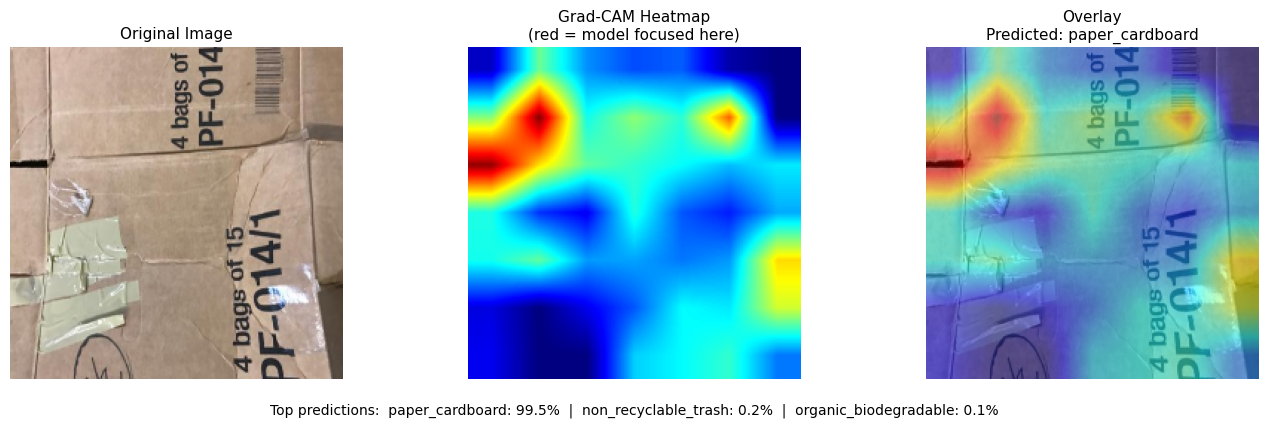

Predicted: paper_cardboard (99.5% confidence)

Class: recyclable_plastic
Saved: C:\Users\ishas\OneDrive\Desktop\ML\Ecolens\models\gradcam_outputs\gradcam_recyclable_plastic.png


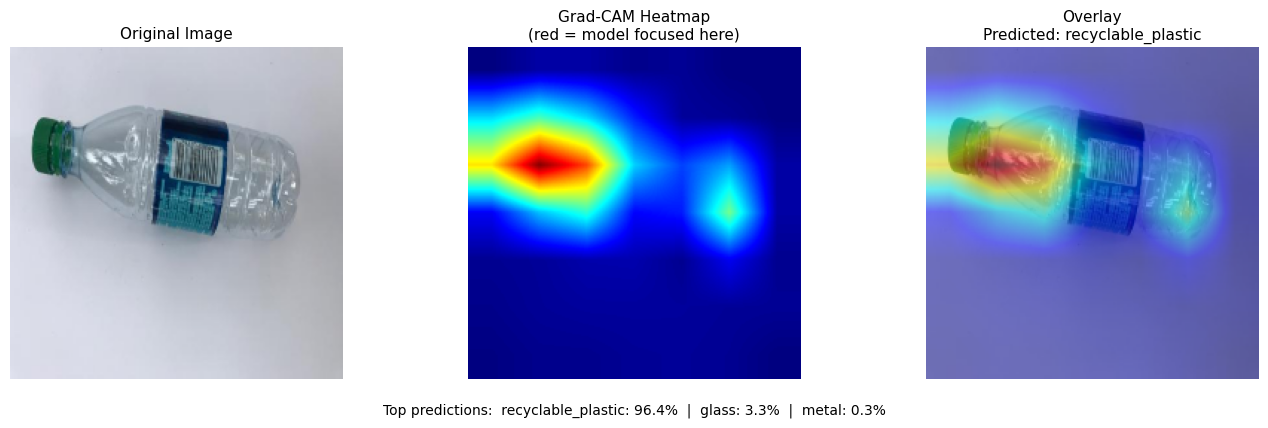

Predicted: recyclable_plastic (96.4% confidence)

All Grad-CAM images saved to models/gradcam_outputs/


In [11]:
gradcam_dir = MODEL_DIR / "gradcam_outputs"
gradcam_dir.mkdir(exist_ok=True)

print("Generating Grad-CAM heatmaps for all 7 classes...")
print("=" * 50)

for class_name in CLASS_NAMES:
    class_folder = TEST_DIR / class_name
    
    # Get first image from this class
    valid_ext = {'.jpg','.jpeg','.png','.JPG','.JPEG','.PNG'}
    images = [f for f in class_folder.iterdir() if f.suffix in valid_ext]
    
    if not images:
        print(f"No images found for {class_name}")
        continue
    
    img_path  = images[0]
    save_path = gradcam_dir / f"gradcam_{class_name}.png"
    
    print(f"\nClass: {class_name}")
    pred_idx, probs = visualize_gradcam(
        img_path, gradcam, IDX_TO_CLASS,
        save_path=save_path
    )
    print(f"Predicted: {IDX_TO_CLASS[pred_idx]} "
          f"({probs[pred_idx].item()*100:.1f}% confidence)")

print("\nAll Grad-CAM images saved to models/gradcam_outputs/")